In [7]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()





wr20_n19_ee = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNEltoElElJJ_MWR2000_N1900_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/120000/8671fc68-7035-485a-935c-21955b49f582.root"
wr40_n39_ee= "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNEltoElElJJ_MWR4000_N3900_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/130000/3045224b-9de4-4e2f-aa22-b670feaccd66.root"
wr60_n59_ee= "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNEltoElElJJ_MWR6000_N5900_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/130000/f3687341-4e56-4872-a512-d338e9548441.root"


wr20_n19_mm = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNMutoMuMuJJ_MWR2000_N1900_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/2810000/3bbe7289-b1e7-40ea-8816-c8b54f904bee.root"
wr40_n39_mm = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNMutoMuMuJJ_MWR4000_N3900_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/120000/9ec067dc-43c0-4556-ad41-b921d0b1f2ae.root"
wr60_n59_mm = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNMutoMuMuJJ_MWR6000_N5900_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/120000/d1095abb-5b48-4ea8-9d75-2feb76f822e4.root"
file1 = uproot.open(wr20_n19_ee)
file2 = uproot.open(wr40_n39_ee)
file3 = uproot.open(wr60_n59_ee)

file4 = uproot.open(wr20_n19_mm)
file5 = uproot.open(wr40_n39_mm)
file6 = uproot.open(wr60_n59_mm)

[444, 279, 86, 117, 117, 344, 751, ..., 300, 498, 389, 316, 119, 471, 1.32e+03]
[38.3, 105, 116, 208, 89, 71.8, 43.4, ..., 153, 354, 103, 85, 159, 532, 2.5e+03]
[444, 279, 116, 208, 117, 344, 751, ..., 300, 498, 389, 316, 159, 532, 2.5e+03]


## WR2000 N 1900 

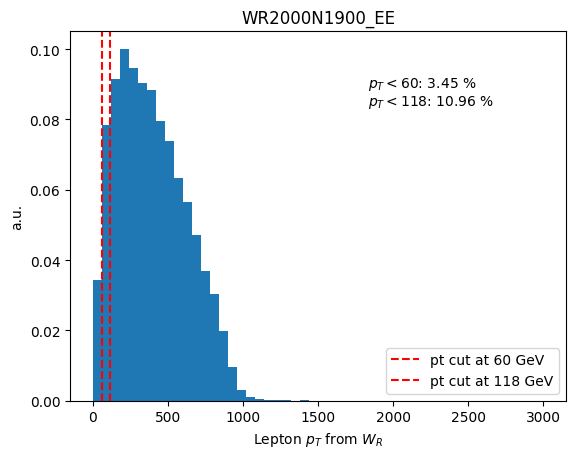

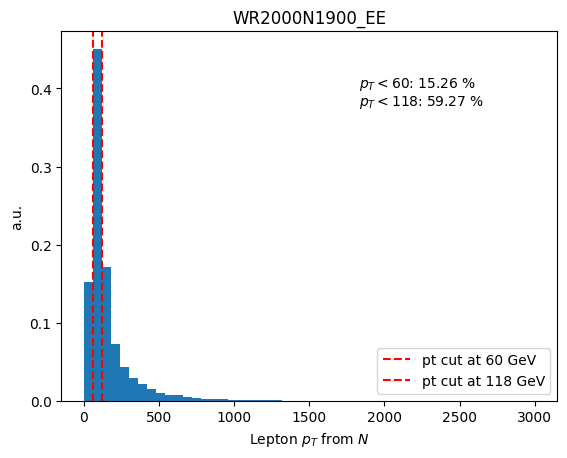

In [20]:
events = file1["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]

# numpy로 변환 (hist/weights 안정성)
wr_vals = ak.to_numpy(wr_np)
n_vals  = ak.to_numpy(n_np)

# 정규화 가중치 (a.u.)
w_wr = np.ones(len(wr_vals)) / len(wr_vals)
w_n  = np.ones(len(n_vals)) / len(n_vals)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(wr_vals < 60) / len(wr_vals) * 100
wr_lt118 = np.sum(wr_vals < 118) / len(wr_vals) * 100

n_lt60  = np.sum(n_vals < 60) / len(n_vals) * 100
n_lt118  = np.sum(n_vals < 118) / len(n_vals) * 100

plt.hist(wr_vals, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Lepton $p_{T}$ from $W_{R}$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.axvline(118, color='red', linestyle='--', label='pt cut at 118 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)
plt.text(0.60, 0.80, f"$p_{{T}} < 118$: {wr_lt118:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.title("WR2000N1900_EE")
plt.savefig("WR2000N1900_lepton_pt_from_WR_EE.png")  # ✅ 그래프 저장

plt.show()

plt.hist(n_vals, bins=50, range=(0, 3000), weights=w_n)
plt.xlabel("Lepton $p_{T}$ from $N$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.axvline(118, color='red', linestyle='--', label='pt cut at 118 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {n_lt60:.2f} %", transform=plt.gca().transAxes)
plt.text(0.60, 0.80, f"$p_{{T}} < 118$: {n_lt118:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.title("WR2000N1900_EE")
plt.savefig("WR2000N1900_lepton_pt_from_N_EE.png") 
plt.show()


## WR 4000 N 3900

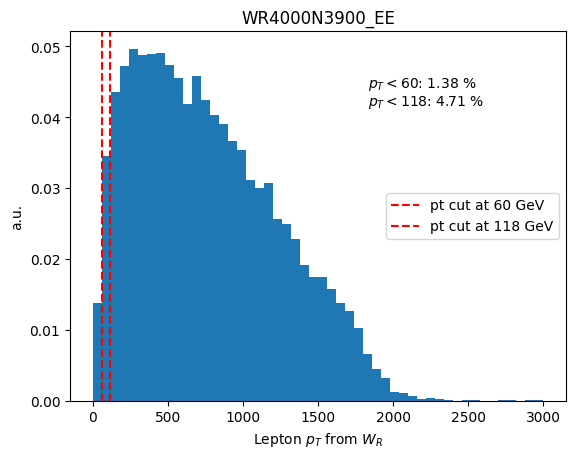

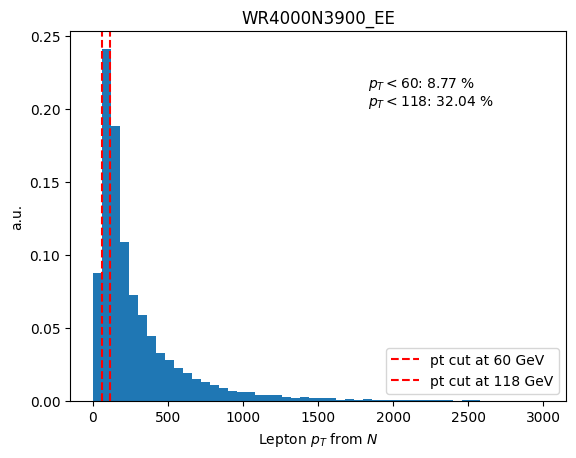

In [22]:
events = file2["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]

# numpy로 변환 (hist/weights 안정성)
wr_vals = ak.to_numpy(wr_np)
n_vals  = ak.to_numpy(n_np)

# 정규화 가중치 (a.u.)
w_wr = np.ones(len(wr_vals)) / len(wr_vals)
w_n  = np.ones(len(n_vals)) / len(n_vals)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(wr_vals < 60) / len(wr_vals) * 100
wr_lt118 = np.sum(wr_vals < 118) / len(wr_vals) * 100

n_lt60  = np.sum(n_vals < 60) / len(n_vals) * 100
n_lt118  = np.sum(n_vals < 118) / len(n_vals) * 100

plt.hist(wr_vals, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Lepton $p_{T}$ from $W_{R}$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.axvline(118, color='red', linestyle='--', label='pt cut at 118 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)
plt.text(0.60, 0.80, f"$p_{{T}} < 118$: {wr_lt118:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.title("WR4000N3900_EE")
plt.savefig("WR4000N3900_lepton_pt_from_WR_EE.png")  # ✅ 그래프 저장
plt.show()

plt.hist(n_vals, bins=50, range=(0, 3000), weights=w_n)
plt.xlabel("Lepton $p_{T}$ from $N$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.axvline(118, color='red', linestyle='--', label='pt cut at 118 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {n_lt60:.2f} %", transform=plt.gca().transAxes)
plt.text(0.60, 0.80, f"$p_{{T}} < 118$: {n_lt118:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.title("WR4000N3900_EE")
plt.savefig("WR4000N3900_lepton_pt_from_N_EE.png")  # ✅ 그래프 저장
plt.show()


## WR 6000 N 5900

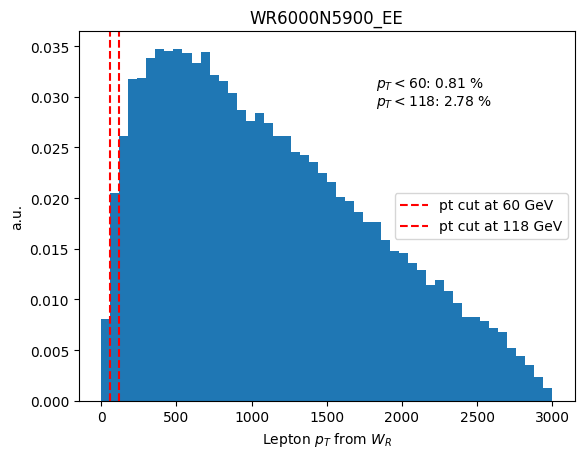

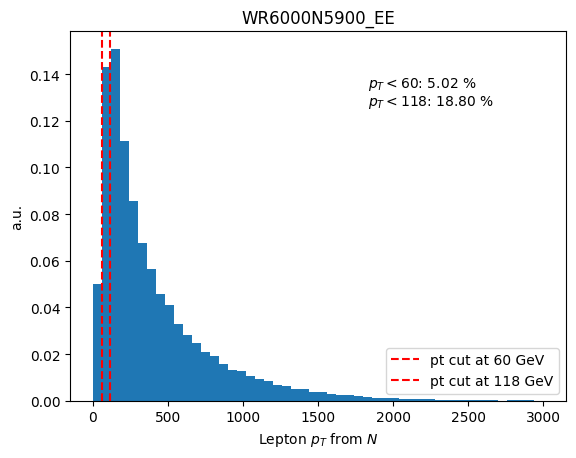

In [23]:
events = file3["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]

# numpy로 변환 (hist/weights 안정성)
wr_vals = ak.to_numpy(wr_np)
n_vals  = ak.to_numpy(n_np)

# 정규화 가중치 (a.u.)
w_wr = np.ones(len(wr_vals)) / len(wr_vals)
w_n  = np.ones(len(n_vals)) / len(n_vals)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(wr_vals < 60) / len(wr_vals) * 100
wr_lt30 = np.sum(wr_vals < 118) / len(wr_vals) * 100

n_lt60  = np.sum(n_vals < 60) / len(n_vals) * 100
n_lt118  = np.sum(n_vals < 118) / len(n_vals) * 100

plt.hist(wr_vals, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Lepton $p_{T}$ from $W_{R}$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.axvline(118, color='red', linestyle='--', label='pt cut at 118 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)
plt.text(0.60, 0.80, f"$p_{{T}} < 118$: {wr_lt30:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.title("WR6000N5900_EE")
plt.savefig("WR6000N5900_lepton_pt_from_WR_EE.png")  # ✅ 그래프 저장
plt.show()

plt.hist(n_vals, bins=50, range=(0, 3000), weights=w_n)
plt.xlabel("Lepton $p_{T}$ from $N$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.axvline(118, color='red', linestyle='--', label='pt cut at 118 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {n_lt60:.2f} %", transform=plt.gca().transAxes)
plt.text(0.60, 0.80, f"$p_{{T}} < 118$: {n_lt118:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.title("WR6000N5900_EE")
plt.savefig("WR6000N5900_lepton_pt_from_N_EE.png")  # ✅ 그래프 저장
plt.show()


## Muon

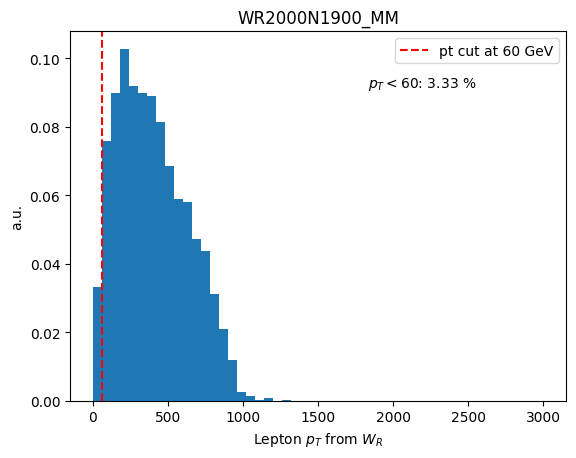

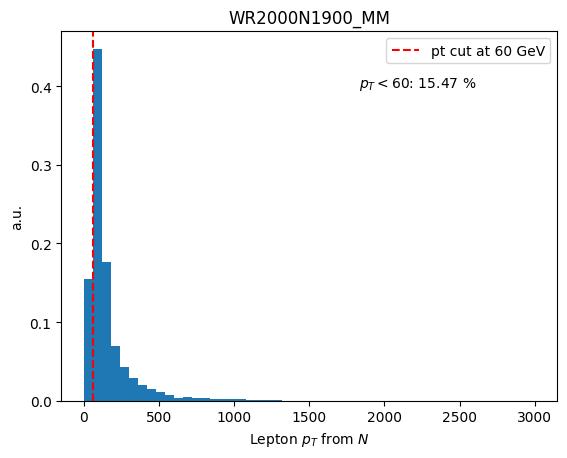

In [24]:
events = file4["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]

# numpy로 변환 (hist/weights 안정성)
wr_vals = ak.to_numpy(wr_np)
n_vals  = ak.to_numpy(n_np)

# 정규화 가중치 (a.u.)
w_wr = np.ones(len(wr_vals)) / len(wr_vals)
w_n  = np.ones(len(n_vals)) / len(n_vals)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(wr_vals < 60) / len(wr_vals) * 100


n_lt60  = np.sum(n_vals < 60) / len(n_vals) * 100


plt.hist(wr_vals, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Lepton $p_{T}$ from $W_{R}$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')

plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)

plt.legend()
plt.title("WR2000N1900_MM")
plt.savefig("WR2000N1900_lepton_pt_from_WR_MM.png")  # ✅ 그래프 저장

plt.show()

plt.hist(n_vals, bins=50, range=(0, 3000), weights=w_n)
plt.xlabel("Lepton $p_{T}$ from $N$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')

plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {n_lt60:.2f} %", transform=plt.gca().transAxes)

plt.legend()
plt.title("WR2000N1900_MM")
plt.savefig("WR2000N1900_lepton_pt_from_N_MM.png") 
plt.show()


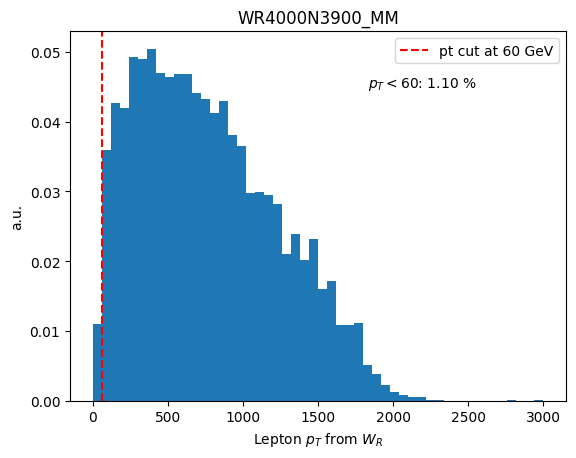

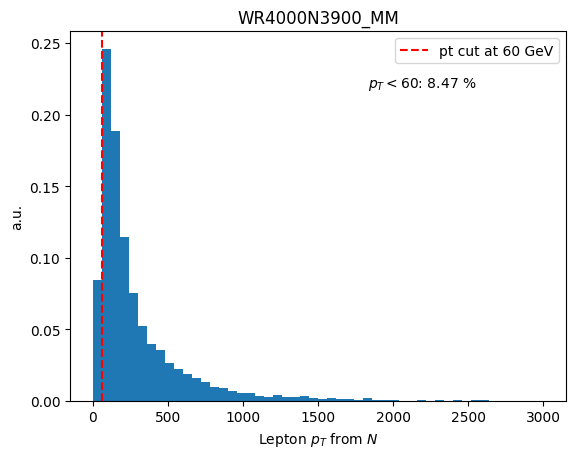

In [25]:
events = file5["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]

# numpy로 변환 (hist/weights 안정성)
wr_vals = ak.to_numpy(wr_np)
n_vals  = ak.to_numpy(n_np)

# 정규화 가중치 (a.u.)
w_wr = np.ones(len(wr_vals)) / len(wr_vals)
w_n  = np.ones(len(n_vals)) / len(n_vals)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(wr_vals < 60) / len(wr_vals) * 100


n_lt60  = np.sum(n_vals < 60) / len(n_vals) * 100


plt.hist(wr_vals, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Lepton $p_{T}$ from $W_{R}$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')

plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)

plt.legend()
plt.title("WR4000N3900_MM")
plt.savefig("WR4000N3900_lepton_pt_from_WR_MM.png")  # ✅ 그래프 저장
plt.show()

plt.hist(n_vals, bins=50, range=(0, 3000), weights=w_n)
plt.xlabel("Lepton $p_{T}$ from $N$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')

plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {n_lt60:.2f} %", transform=plt.gca().transAxes)

plt.legend()
plt.title("WR4000N3900_MM")
plt.savefig("WR4000N3900_lepton_pt_from_N_MM.png")  # ✅ 그래프 저장
plt.show()


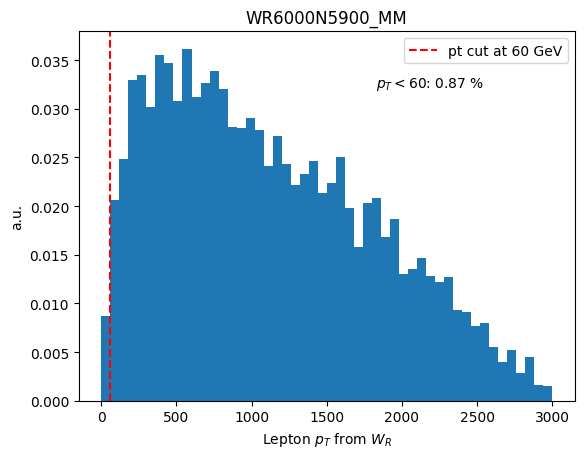

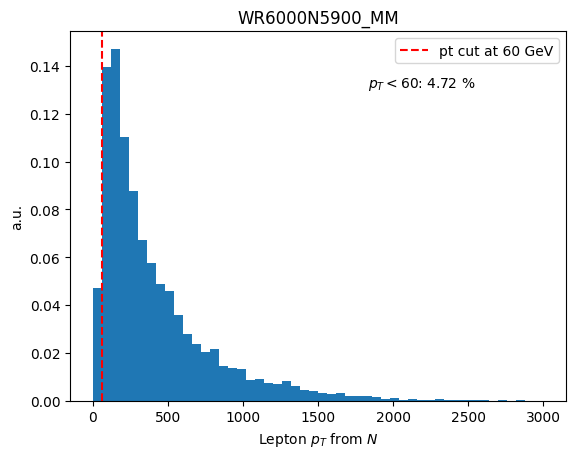

In [26]:
events = file6["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]

# numpy로 변환 (hist/weights 안정성)
wr_vals = ak.to_numpy(wr_np)
n_vals  = ak.to_numpy(n_np)

# 정규화 가중치 (a.u.)
w_wr = np.ones(len(wr_vals)) / len(wr_vals)
w_n  = np.ones(len(n_vals)) / len(n_vals)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(wr_vals < 60) / len(wr_vals) * 100


n_lt60  = np.sum(n_vals < 60) / len(n_vals) * 100


plt.hist(wr_vals, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Lepton $p_{T}$ from $W_{R}$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')

plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)

plt.legend()
plt.title("WR6000N5900_MM")
plt.savefig("WR6000N5900_lepton_pt_from_WR_MM.png")  # ✅ 그래프 저장
plt.show()

plt.hist(n_vals, bins=50, range=(0, 3000), weights=w_n)
plt.xlabel("Lepton $p_{T}$ from $N$")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')

plt.text(0.60, 0.85, f"$p_{{T}} < 60$: {n_lt60:.2f} %", transform=plt.gca().transAxes)

plt.legend()
plt.title("WR6000N5900_MM")
plt.savefig("WR6000N5900_lepton_pt_from_N_MM.png")  # ✅ 그래프 저장
plt.show()


## Checking leading pt only 

[444, 279, 116, 208, 117, 344, 751, ..., 300, 498, 389, 316, 159, 532, 2.5e+03]


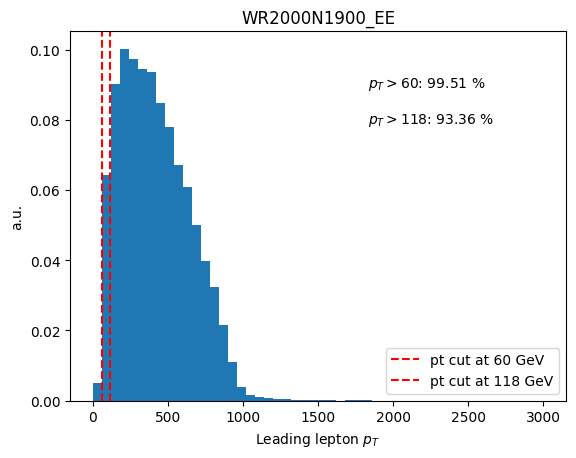

In [33]:
events = file1["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]
harder_pt = np.maximum(wr_np, n_np)

print(harder_pt)


# 정규화 가중치 (a.u.)
w_wr = np.ones(len(harder_pt)) / len(harder_pt)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(harder_pt > 60) / len(harder_pt) * 100

wr_lt118 = np.sum(harder_pt > 118) / len(harder_pt) * 100



plt.hist(harder_pt, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Leading lepton $p_{T}$ ")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.axvline(118, color='red', linestyle='--', label='pt cut at 118 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} > 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)
plt.text(0.60, 0.75, f"$p_{{T}} > 118$: {wr_lt118:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.title("WR2000N1900_EE")
plt.savefig("WR2000N1900_lepton_EE_pt.png")  # ✅ 그래프 저장
plt.show()






[1.72e+03, 513, 341, 640, 1.76e+03, ..., 327, 1.32e+03, 294, 150, 1.23e+03]


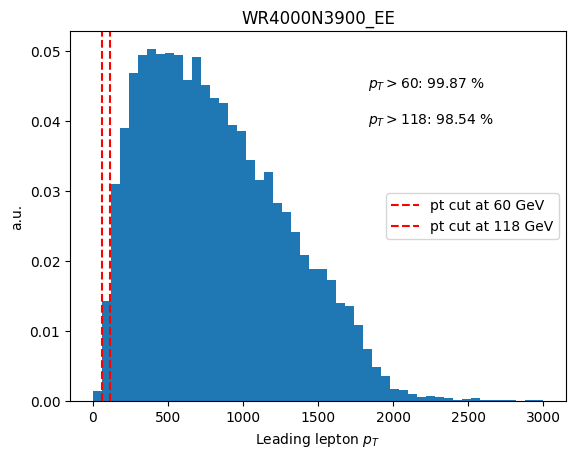

In [34]:
events = file2["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]
harder_pt = np.maximum(wr_np, n_np)

print(harder_pt)


# 정규화 가중치 (a.u.)
w_wr = np.ones(len(harder_pt)) / len(harder_pt)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(harder_pt > 60) / len(harder_pt) * 100

wr_lt118 = np.sum(harder_pt > 118) / len(harder_pt) * 100



plt.hist(harder_pt, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Leading lepton $p_{T}$ ")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.axvline(118, color='red', linestyle='--', label='pt cut at 118 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} > 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)
plt.text(0.60, 0.75, f"$p_{{T}} > 118$: {wr_lt118:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.title("WR4000N3900_EE")
plt.savefig("WR4000N3900_lepton_EE_pt.png")  # ✅ 그래프 저장
plt.show()






[892, 847, 643, 1.12e+03, 1.22e+03, 499, ..., 1.62e+03, 672, 641, 417, 504]


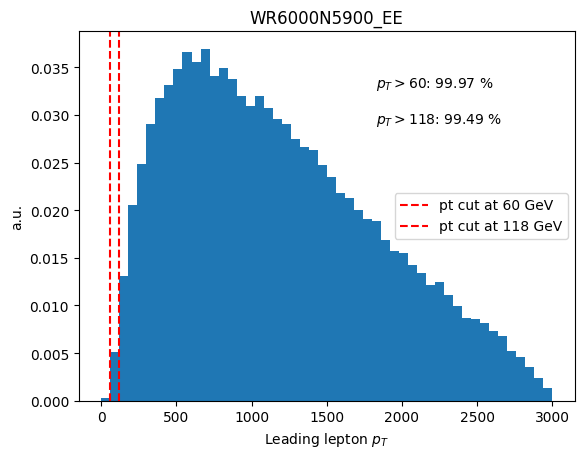

In [35]:
events = file3["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]
harder_pt = np.maximum(wr_np, n_np)

print(harder_pt)


# 정규화 가중치 (a.u.)
w_wr = np.ones(len(harder_pt)) / len(harder_pt)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(harder_pt > 60) / len(harder_pt) * 100

wr_lt118 = np.sum(harder_pt > 118) / len(harder_pt) * 100



plt.hist(harder_pt, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Leading lepton $p_{T}$ ")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')
plt.axvline(118, color='red', linestyle='--', label='pt cut at 118 GeV')
plt.text(0.60, 0.85, f"$p_{{T}} > 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)
plt.text(0.60, 0.75, f"$p_{{T}} > 118$: {wr_lt118:.2f} %", transform=plt.gca().transAxes)
plt.legend()
plt.title("WR6000N5900_EE")
plt.savefig("WR6000N5900_lepton_EE_pt.png")  # ✅ 그래프 저장
plt.show()






[233, 276, 180, 451, 535, 601, 722, ..., 475, 436, 448, 198, 294, 73.7, 382]


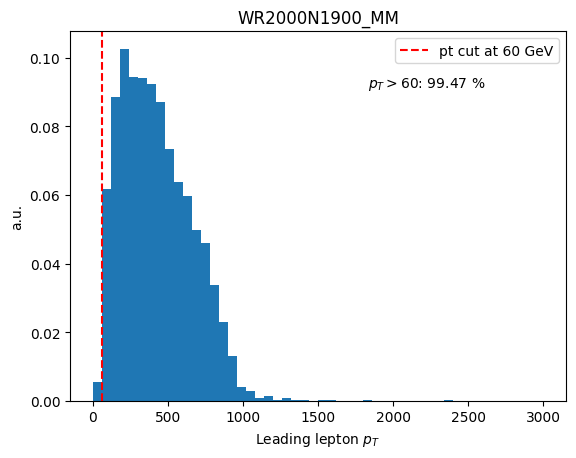

In [36]:
events = file4["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]
harder_pt = np.maximum(wr_np, n_np)

print(harder_pt)


# 정규화 가중치 (a.u.)
w_wr = np.ones(len(harder_pt)) / len(harder_pt)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(harder_pt > 60) / len(harder_pt) * 100





plt.hist(harder_pt, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Leading lepton $p_{T}$ ")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')

plt.text(0.60, 0.85, f"$p_{{T}} > 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)

plt.legend()
plt.title("WR2000N1900_MM")
plt.savefig("WR2000N1900_lepton_MM_pt.png")  # ✅ 그래프 저장
plt.show()






[1.35e+03, 1.18e+03, 83.5, 748, 1.2e+03, ..., 1.47e+03, 867, 809, 1.48e+03, 374]


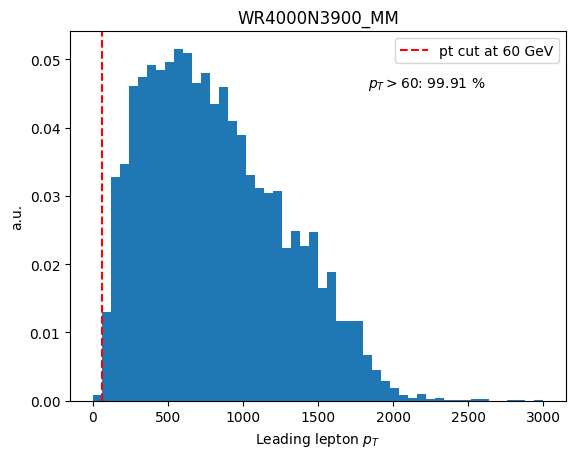

In [37]:
events = file5["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]
harder_pt = np.maximum(wr_np, n_np)

print(harder_pt)


# 정규화 가중치 (a.u.)
w_wr = np.ones(len(harder_pt)) / len(harder_pt)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(harder_pt > 60) / len(harder_pt) * 100





plt.hist(harder_pt, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Leading lepton $p_{T}$ ")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')

plt.text(0.60, 0.85, f"$p_{{T}} > 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)

plt.legend()
plt.title("WR4000N3900_MM")
plt.savefig("WR4000N3900_lepton_MM_pt.png")  # ✅ 그래프 저장
plt.show()






[2.48e+03, 1.11e+03, 1.54e+03, 580, 700, ..., 1.65e+03, 1.15e+03, 461, 985, 526]


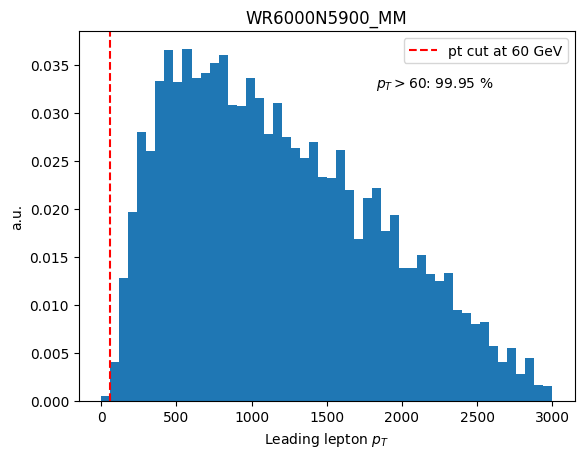

In [38]:
events = file6["Events"]
lhe_pt = events["LHEPart_pt"].array()

wr_np = lhe_pt[:, 2]
n_np  = lhe_pt[:, -1]
harder_pt = np.maximum(wr_np, n_np)

print(harder_pt)


# 정규화 가중치 (a.u.)
w_wr = np.ones(len(harder_pt)) / len(harder_pt)

# pt < 60 GeV 이벤트 비율 (%)
wr_lt60 = np.sum(harder_pt > 60) / len(harder_pt) * 100





plt.hist(harder_pt, bins=50, range=(0, 3000), weights=w_wr)
plt.xlabel("Leading lepton $p_{T}$ ")
plt.ylabel("a.u.")
plt.axvline(60, color='red', linestyle='--', label='pt cut at 60 GeV')

plt.text(0.60, 0.85, f"$p_{{T}} > 60$: {wr_lt60:.2f} %", transform=plt.gca().transAxes)


plt.legend()
plt.title("WR6000N5900_MM")
plt.savefig("WR6000N5900_lepton_MM_pt.png")  # ✅ 그래프 저장
plt.show()




